# Этап3: проверка гипотез
*Выполнила: Мария Васильева*

## План:
1. Формулировка гипотез: нулевой и альтернативной
3. Выбор статкритерия
4. Расчет параметров эксперимента
5. Интерпретация результатов

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.stats as st
import pingouin as pg
from scipy import stats
from scipy.stats import ttest_ind
from scipy.stats import spearmanr

In [116]:
df = pd.read_csv('/Users/mariavasilyeva/HSE/Project/dataframe.csv')

In [84]:
df.sample(3)

,student_id,age,gender,grade_level,study_hours_per_day,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,ai_generated_content_percentage,...,final_score,passed,performance_category,ai_ethics_risk,engagement_index,study_sleep_balance,social_distraction_index,score_consistency_gap,emotional_instability,uses_ai
958,959,17,Female,11th,2.2,81,Claude,Coding,9,95,...,39.5,0,Low,0.95,0.505722,0.500000,0.972973,43.8,0.282582,1
71,72,17,Male,10th,5.2,95,Unknown,Exam Prep,2,87,...,80.9,1,High,0.00,0.654286,0.945455,0.226190,9.6,0.186096,1
3445,3446,14,Female,11th,2.5,82,Gemini,Unknown,10,94,...,32.0,0,Low,0.94,0.519743,0.595238,0.512195,15.4,0.456545,1


In [7]:
df.ai_usage_purpose.unique()

array(['Exam Prep', 'Notes', 'Doubt Solving', 'Coding', 'Unknown',
       'Homework'], dtype=object)

In [18]:
df_raw = pd.read_csv('/Users/mariavasilyeva/HSE/Project/ai_impact_student_performance_dataset.csv')

In [20]:
df = df.merge(df_raw[['student_id', 'uses_ai']], on = 'student_id', how = 'left')

In [21]:
df.loc[df['uses_ai'] == 0, ['ai_usage_time_minutes', 'ai_tools_used', 'ai_usage_purpose', 'ai_dependency_score', 'ai_generated_content_percentage', 'ai_prompts_per_week', 'ai_ethics_score']] = 0

In [24]:
df_control = df.query('uses_ai == 0')

In [25]:
df_test = df.query('uses_ai == 1')

# ГИПОТЕЗА 1. Использование AI tools связано с более высокой успеваемостью

- H0: средний final_score одинаков у студентов с uses_ai = 1 и uses_ai = 0
- H1: средний final_score выше у студентов, использующих AI

## Что сравниваем:

- группы: uses_ai = 1 vs 0
- метрика: final_score

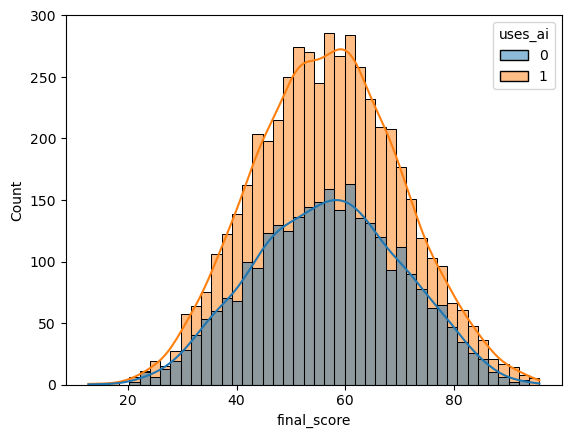

In [86]:
# проверка нормальности распределения
sns.histplot(data=df, x='final_score', hue='uses_ai', kde=True);

Оба распределения примерно колоколообразные без сильных перекосов и выбросов, похожи.

## Выбор теста:
- Группы независимы, можно использовать t-test и сравнивать средние значения.
- Уровень значимости альфа = 0.05
- Ошибка II рода бета=0.2, тогда мощность 0.8

In [89]:
group_ai = df[df['uses_ai'] == 1]['final_score']
group_no_ai = df[df['uses_ai'] == 0]['final_score']

ttest_ind(group_ai, group_no_ai, equal_var=False)

TtestResult(statistic=-0.14539643045346998, pvalue=0.8844028349058273, df=5917.383021528779)

In [94]:
# размер эффекта
diff = group_ai.mean() - group_no_ai.mean()
diff

-0.04566762196950691

## Гипотеза 1: вывод

p-value = 0.88>0.05 значит **нет оснований отвергать нулевую гипотезу** о равенстве средних значений в `final score`.
размер эффекта 0.05 незначителен (учитывая бальную шкалу от 0 до 100)

# ГИПОТЕЗА 2. Интенсивность использования AI влияет на успеваемость

- H0: нет связи между временем использвоания AI (ai_usage_time_minutes) и итоговым баллом (final_score)
- H1: есть положительная (или нелинейная) связь

## Что сравниваем:
- корреляция: ai_usage_time_minutes ↔ final_score
  
## Выбор теста:
- Spearman

<Axes: xlabel='ai_usage_time_minutes', ylabel='final_score'>

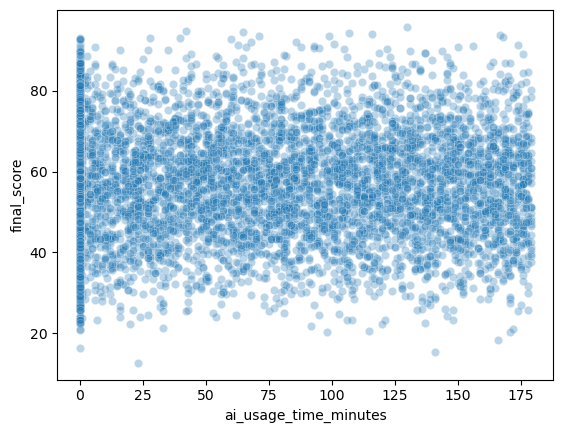

In [99]:
sns.scatterplot(data=df, x='ai_usage_time_minutes', y='final_score', alpha=0.3)

In [98]:
corr, p_value = spearmanr(df['ai_usage_time_minutes'], df['final_score'])
corr, p_value

(-0.004949994598709411, 0.6580011859057078)

## Гипотеза 2: вывод

- p-value = 0.65 > 0.05, значит нет статистически значимой связи.
- коэффициент корреляции -0.0049 - связь фактически отсутсвует.

Можем сделать вывод, что **количество времени, затраченного на использвоание AI tools** `ai_usage_time_minutes` **не связано с академической успеваемостью студентов**

# ГИПОТЕЗА 3. Зависимость от AI (опора на AI) влияет на академичесий результат студентов

- H0: ai_dependency_score не связан с final_score
- H1: есть зависимость успеваемость от ai_dependency_score 


## Выбор теста:
- корреляция (Spearman)
- сравнение: low / medium / high dependency

In [119]:
corr, p_value = spearmanr(df['ai_dependency_score'], df['final_score'])
corr, p_value

(0.013586278702426933, 0.22434324759183005)

In [120]:
df['dependency_group'] = pd.cut(
    df['ai_dependency_score'],
    bins=[-1, 3, 7, 10],
    labels=['low', 'medium', 'high']
)

In [121]:
df.groupby('dependency_group')['final_score'].mean()

/var/folders/x0/96cbl7b15kv50ff1f4qnsnz40000gn/T/ipykernel_97499/4115916133.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('dependency_group')['final_score'].mean()


dependency_group
low       56.606593
medium    56.598752
high      57.293413
Name: final_score, dtype: float64

## Гипотеза 3: вывод
Корреляционый анализ Спирмена не выявил значительной связи между зависисмостью от AI `ai_dependency_score` и итоговой оценкой `final_score`:
- коэффициент корреляции = 0.003,
- p-value = 0.81.

Кроме того, сравнение групп с разным уровнем зависимости показало близкие средние значения баллов. Это указывает, что зависисмость (или опора на AI) не оказывает влияния на успеваемость.

# Гипотеза 4: Студенты с постоянным уровнем успеваемости демонстрируют более высокую успеваемость

- H0: `score_consistency_gap` не связан с `final_score`, то есть не влияет на итоговую оценку
- H1: С увеличением `score_consistency_gap` итоговый балл снижается

## Выбор теста:
- корреляция (Spearman)
- проверка по группам `score_consistency_gap`

In [122]:
corr, p_value = spearmanr(df['score_consistency_gap'], df['final_score'])
corr, p_value

(-0.05012712975904653, 7.270014236403944e-06)

In [123]:
df['consistency_group'] = pd.qcut(
    df['score_consistency_gap'],
    q=3,
    labels=['stable', 'medium', 'unstable'],
    duplicates='drop'
)
df.groupby('consistency_group')['final_score'].mean()

/var/folders/x0/96cbl7b15kv50ff1f4qnsnz40000gn/T/ipykernel_97499/2611037593.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('consistency_group')['final_score'].mean()


consistency_group
stable      57.514639
medium      56.880480
unstable    56.039287
Name: final_score, dtype: float64

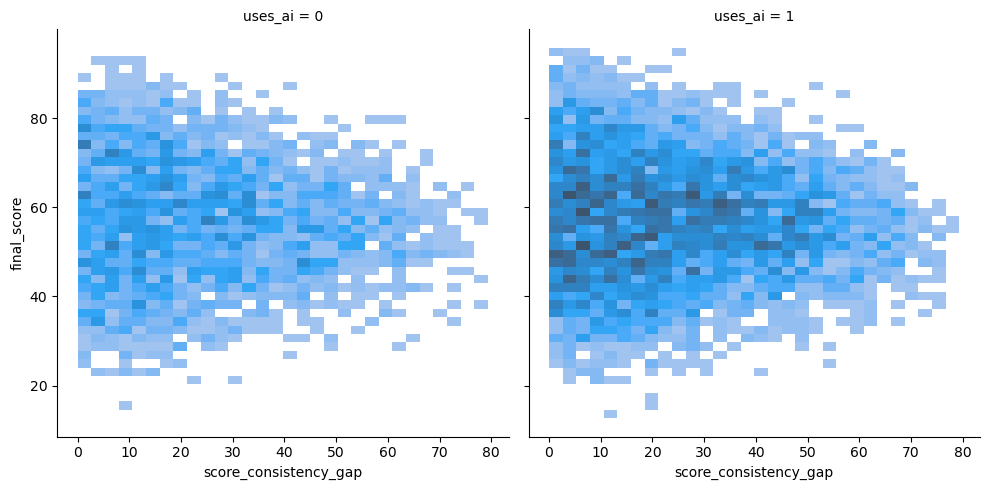

In [35]:
sns.displot(
    data=df,
    x='score_consistency_gap',
    y='final_score',
    col='uses_ai'
)

## Гипотеза 4: Вывод
- p-value << 0.05, связь есть!
- corr<0 значит чем больше `score_consistency_gap`, то есть чем менее стабильна успеваемость, тем ниже итоговая оценка.
  
**Однако коэффициент корреляции довольно низкий, связь слабая.**
Сравнение групп показывает, что разница между этими группами тоже мала, хотя и имеет такое направление (более стабильные оценки -> более высокие оценки).
То есть эффект есть, но очень мал.

# Гипотеза 5: Студенты с более высокой эмоциональной стабильностью демонстрируют более высокую успеваемость

- H0: `emotional_instability` не связан с `final_score`
- H1: С увеличением emotional_instability итоговый балл снижается, то есть: чем выше нестабильность, тем хуже результат)

## Выбор теста:
- корреляция (Spearman)

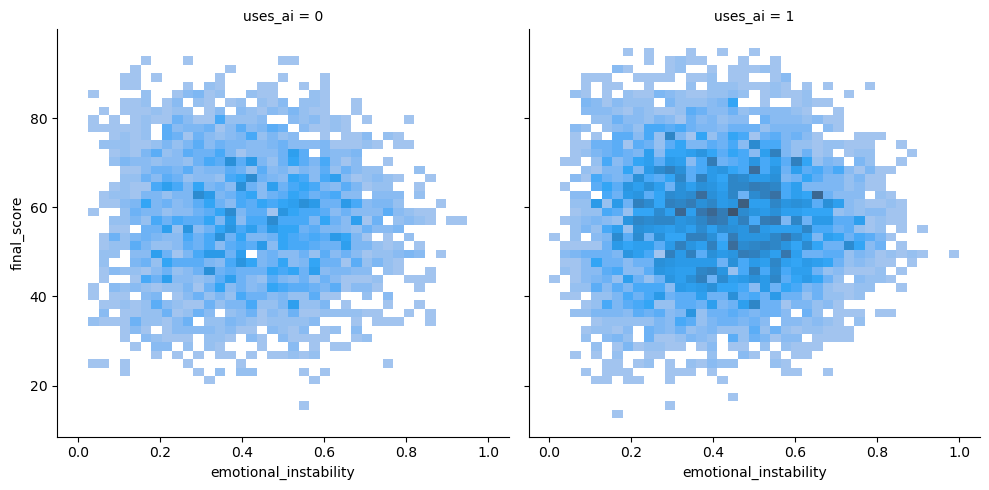

In [34]:
sns.displot(
    data=df,
    x='emotional_instability',
    y='final_score',
    col='uses_ai'
) # визуализация не показывает каких-то заметных различий в тренде

In [124]:
corr, p_value = spearmanr(df['emotional_instability'], df['final_score'])
corr, p_value

(-0.015781929727239175, 0.15811313960667658)

## Гипотеза 4: Вывод
- p-value > 0.05, значит нет оснований отклонять нудевую гипотезу
значение коэффициента корреляции отрицательное, но очень близко к нулю, мождно утверждать, что связь отсутсвует фактически